<a href="https://colab.research.google.com/github/CHIN-HUA/CHIN-HUA/blob/main/AiChip_Midterm_project_ML_modeling_of_IV_Curves_GPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Running L=0.35 W=1.0
Running L=0.35 W=6.0
Running L=0.35 W=11.0
Running L=0.35 W=16.0
Running L=0.35 W=21.0
Running L=0.35 W=26.0
Running L=0.35 W=31.0
Running L=0.35 W=36.0
Running L=0.35 W=41.0
Running L=0.35 W=46.0
Running L=0.35 W=51.0
Running L=0.40 W=1.0
Running L=0.40 W=6.0
Running L=0.40 W=11.0
Running L=0.40 W=16.0
Running L=0.40 W=21.0
Running L=0.40 W=26.0
Running L=0.40 W=31.0
Running L=0.40 W=36.0
Running L=0.40 W=41.0
Running L=0.40 W=46.0
Running L=0.40 W=51.0
Running L=0.45 W=1.0
Running L=0.45 W=6.0
Running L=0.45 W=11.0
Running L=0.45 W=16.0
Running L=0.45 W=21.0
Running L=0.45 W=26.0
Running L=0.45 W=31.0
Running L=0.45 W=36.0
Running L=0.45 W=41.0
Running L=0.45 W=46.0
Running L=0.45 W=51.0
Running L=0.50 W=1.0
Running L=0.50 W=6.0
Running L=0.50 W=11.0
Running L=0.50 W=16.0
Runni

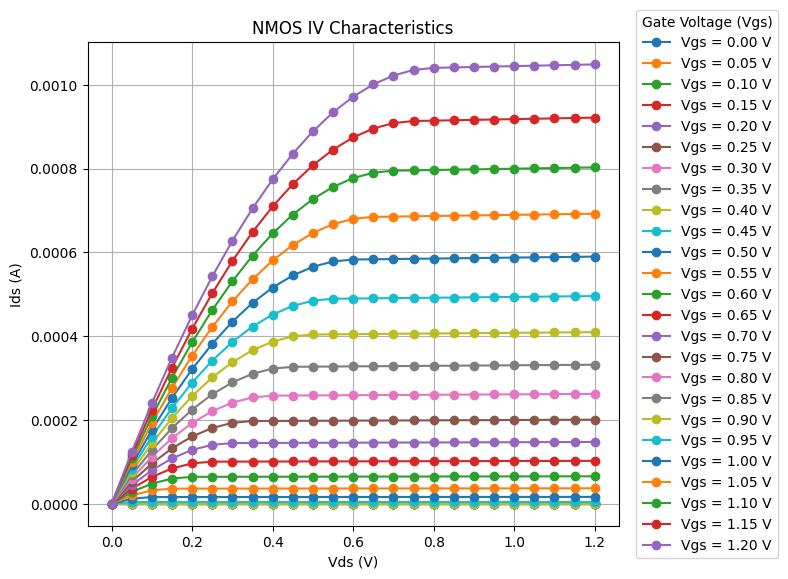

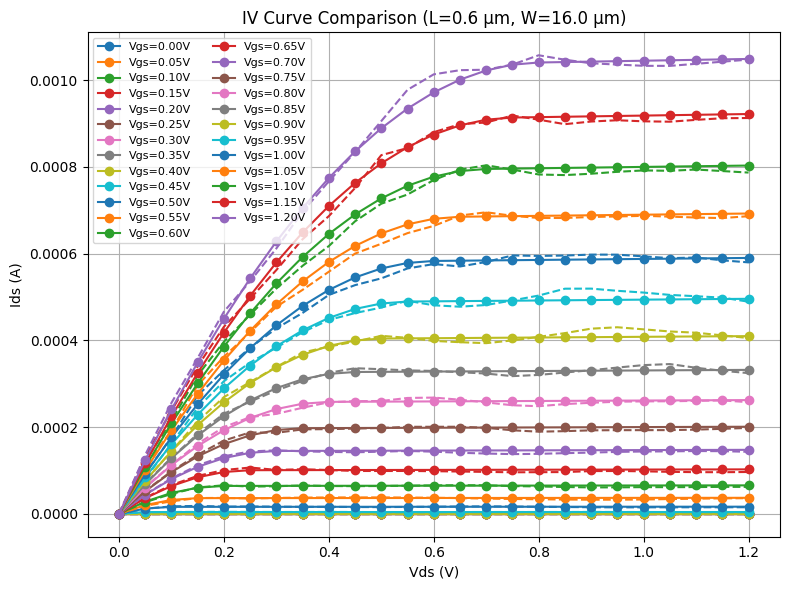

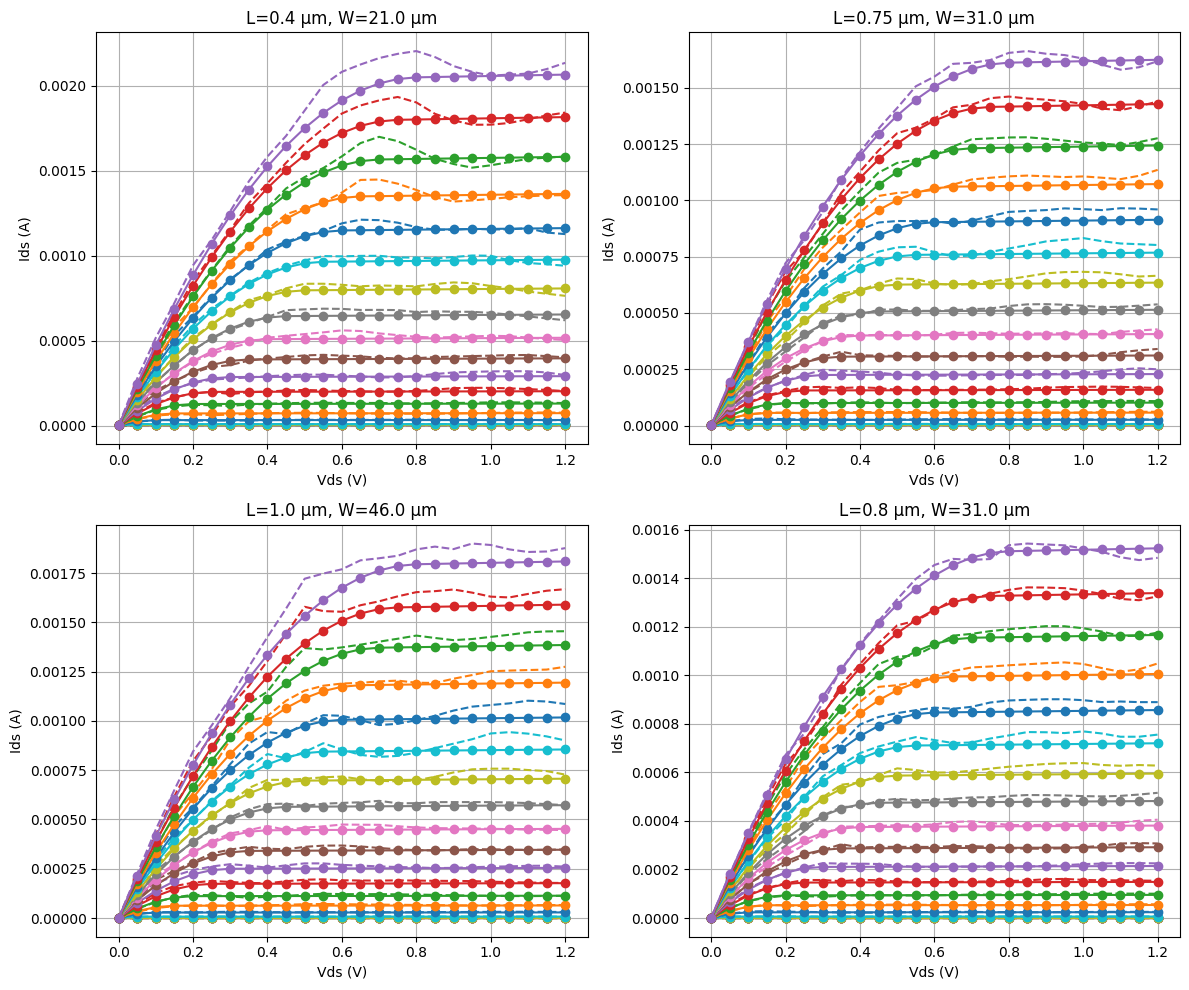

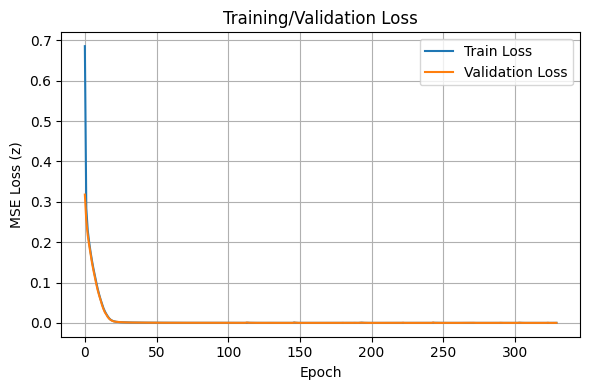

In [3]:
# ============================================================
# 0. 安裝環境 (只需執行一次)
# ============================================================
!apt-get -qq update
!apt-get -qq install -y ngspice
!pip install pandas scikit-learn matplotlib torch --upgrade -q

import os, re, random, textwrap, itertools, subprocess, tempfile
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. 生成 NMOS IV 資料
# ============================================================
NETLIST_TEMPLATE = """
* NMOS IV Simulation
.model nmos nmos (kp=120u Vto=0.4 gamma=0.6 phi=0.7 lambda=0.02)
.param L={L}u W={W}u
Vgs gate 0 0
Vds drain 0 0
M1 drain gate 0 0 nmos L={L}u W={W}u
.dc Vgs 0 1.2 0.05 Vds 0 1.2 0.05
.print dc V(gate) V(drain) I(Vds)
.end
"""

def run_ngspice(L, W, debug=False):
    with tempfile.TemporaryDirectory() as td:
        cir_path = Path(td) / "net.cir"
        cir_path.write_text(NETLIST_TEMPLATE.format(L=L, W=W))

        res = subprocess.run(["ngspice", "-b", str(cir_path)],
                             capture_output=True, text=True)

        if res.returncode != 0:
            if debug:
                print(res.stderr)
            return None

        Vgs, Vds, Ids = [], [], []
        for line in res.stdout.splitlines():
            nums = [float(x) for x in line.split() if re.fullmatch(r"[+-]?\d+(\.\d+)?([eE][+-]?\d+)?", x)]
            if len(nums) >= 3:
                Vgs.append(nums[-3])
                Vds.append(nums[-2])
                Ids.append(abs(nums[-1]))

        if not Vgs:
            return None

        return pd.DataFrame({"Vgs": Vgs, "Vds": Vds, "L": L, "W": W, "Ids": Ids})

# 批量掃描
L_values = np.round(np.arange(0.35, 1.01, 0.05), 2)
W_values = np.round(np.arange(1.0, 51.1, 5.0), 1)

dfs = []
for L, W in itertools.product(L_values, W_values):
    print(f"Running L={L:.2f} W={W:.1f}")
    df_tmp = run_ngspice(L, W)
    if df_tmp is not None:
        dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
print("✅ 資料蒐集完成，筆數 =", len(df))

# ============================================================
# 2. 特徵工程 + 前處理
# ============================================================
df["Ids"] = np.clip(df["Ids"], 1e-15, None)
df["Ids_log"] = np.log10(df["Ids"])

# 輸入特徵
X = df[["Vgs", "Vds", "L", "W"]].values
y = df[["Ids_log"]].values

# 標準化
from sklearn.preprocessing import StandardScaler
# ============================================================
# 3. MLP 模型 (Double Precision)
# ============================================================
class PhysMLP(torch.nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_dim, 128, dtype=torch.float64),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 64, dtype=torch.float64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 32, dtype=torch.float64),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 1, dtype=torch.float64)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PhysMLP(in_dim=4).to(device)


x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y)

X_tensor = torch.tensor(X_scaled, dtype=torch.float64).to(next(model.parameters()).device)

y_tensor = torch.tensor(y_scaled, dtype=torch.float64)

# Train/Val Split
from torch.utils.data import TensorDataset, DataLoader, random_split

dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(len(dataset) * 0.8)
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=4096, shuffle=True)
val_loader = DataLoader(val_set, batch_size=4096)

print(f"Train = {len(train_set)}, Val = {len(val_set)}")

# ============================================================
# 3. MLP 模型 (Double Precision)
# ============================================================
class PhysMLP(torch.nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_dim, 128, dtype=torch.float64),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 64, dtype=torch.float64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 32, dtype=torch.float64),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 1, dtype=torch.float64)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PhysMLP(in_dim=4).to(device)

loss_fn = torch.nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# 4. 訓練模型
# ============================================================
EPOCHS = 500
best_val_loss = float('inf')
early_stop_counter = 0

train_losses, val_losses = [], []

for ep in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        opt.step()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    model.eval()
    with torch.no_grad():
        val_loss = np.mean([
            loss_fn(model(xb.to(device)), yb.to(device)).item()
            for xb, yb in val_loader
        ])

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    if ep % 50 == 0 or ep == 1:
        print(f"Epoch {ep}/{EPOCHS} | Train Loss = {train_loss:.4f} | Val Loss = {val_loss:.4f}")

    if early_stop_counter >= 30:
        print(f"Early stopping at epoch {ep}")
        break

# ============================================================
# 5. 驗證模型表現
# ============================================================
model.eval()
X_full = torch.tensor(X_scaled, dtype=torch.float64).to(device)

with torch.no_grad():
    y_pred_scaled = model(X_full).cpu().numpy()

y_pred_log = y_scaler.inverse_transform(y_pred_scaled)
y_true_log = y

_pred_log10 = y_scaler.inverse_transform(y_scaled)

# 反標準化 + 還原為原始單位
ids_pred = 10 ** y_pred_log.flatten()
ids_true = 10 ** y_true_log.flatten()

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("\n✅  log10(Ids) 空間")
print(f"R²   = {r2_score(y_true_log, y_pred_log):.4f}")
print(f"MAE  = {mean_absolute_error(y_true_log, y_pred_log):.4f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y_true_log, y_pred_log)):.4f}")

print("\n✅  Ids 空間 (Amp)")
print(f"R²   = {r2_score(ids_true, ids_pred):.4f}")
print(f"MAE  = {mean_absolute_error(ids_true, ids_pred):.4e} A")
print(f"RMSE = {np.sqrt(mean_squared_error(ids_true, ids_pred)):.4e} A")

# # ============================================================
# # 6. 畫出隨機 IV 曲線
# # ============================================================
# def plot_random_iv():
#     random_idx = np.random.randint(0, len(df))
#     L_sel, W_sel = df.iloc[random_idx][["L", "W"]]

#     df_sub = df[(df["L"] == L_sel) & (df["W"] == W_sel)].copy()

#     X_sub = df_sub[["Vgs", "Vds", "L", "W"]].values
#     X_sub_scaled = x_scaler.transform(X_sub)
#     X_sub_tensor = torch.tensor(X_sub_scaled, dtype=torch.float64).to(device)

#     with torch.no_grad():
#         y_pred_sub_scaled = model(X_sub_tensor).cpu().numpy()

#     y_pred_sub_log = y_scaler.inverse_transform(y_pred_sub_scaled).flatten()
#     df_sub["Ids_pred"] = 10 ** y_pred_sub_log

#     plt.figure(figsize=(7,5))
#     for vgs in sorted(df_sub["Vgs"].unique()):
#         d = df_sub[df_sub["Vgs"] == vgs]
#         plt.plot(d["Vds"], d["Ids"], 'o', label=f"True Vgs={vgs:.2f}")
#         plt.plot(d["Vds"], d["Ids_pred"], '--', label=f"Pred Vgs={vgs:.2f}")

#     plt.yscale("log")
#     plt.xlabel("Vds (V)")
#     plt.ylabel("Ids (A)")
#     plt.title(f"IV Curve Comparison L={L_sel}μm, W={W_sel}μm")
#     plt.legend(ncol=2, fontsize=7)
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

# plot_random_iv()


# ============================================================
# 6-1. 畫出 Fig.1：模擬資料的 IV 曲線（無預測）
# ============================================================
def plot_ngspice_iv(L_sel=0.6, W_sel=16.0):
    df_sub = df[(df["L"] == L_sel) & (df["W"] == W_sel)].copy()

    plt.figure(figsize=(8, 6))
    for vgs in sorted(df_sub["Vgs"].unique()):
        d = df_sub[df_sub["Vgs"] == vgs]
        plt.plot(d["Vds"], d["Ids"], 'o-', label=f"Vgs = {vgs:.2f} V")

    plt.xlabel("Vds (V)")
    plt.ylabel("Ids (A)")
    plt.title("NMOS IV Characteristics")
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="Gate Voltage (Vgs)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("iv_ngspice_L0.6_W16.0.png")
    plt.show()

plot_ngspice_iv()

# ============================================================
# 6. 畫出 Midterm 格式 IV 曲線 (L=0.6μm, W=16μm)
# ============================================================
def plot_fixed_iv(L_sel=0.6, W_sel=16.0):
    df_sub = df[(df["L"] == L_sel) & (df["W"] == W_sel)].copy()

    X_sub = df_sub[["Vgs", "Vds", "L", "W"]].values
    X_sub_scaled = x_scaler.transform(X_sub)
    X_sub_tensor = torch.tensor(X_sub_scaled, dtype=torch.float64).to(device)

    with torch.no_grad():
        y_pred_sub_scaled = model(X_sub_tensor).cpu().numpy()

    y_pred_sub_log = y_scaler.inverse_transform(y_pred_sub_scaled).flatten()
    df_sub["Ids_pred"] = 10 ** y_pred_sub_log

    plt.figure(figsize=(8, 6))
    for vgs in sorted(df_sub["Vgs"].unique()):
        d = df_sub[df_sub["Vgs"] == vgs]
        plt.plot(d["Vds"], d["Ids"], 'o-', label=f"Vgs={vgs:.2f}V")
        plt.plot(d["Vds"], d["Ids_pred"], '--', color=plt.gca().lines[-1].get_color())

    plt.xlabel("Vds (V)")
    plt.ylabel("Ids (A)")
    plt.title(f"IV Curve Comparison (L={L_sel} µm, W={W_sel} µm)")
    plt.yscale("linear")  # 線性座標
    plt.legend(loc="best", ncol=2, fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"iv_comparison_L{L_sel}_W{W_sel}.png")
    plt.show()

plot_fixed_iv()

def plot_4_random_devices(df, model, x_scaler, y_scaler):
    import matplotlib.pyplot as plt
    import torch

    pairs = df[["L", "W"]].drop_duplicates().sample(4, random_state=42).values
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for ax, (L_sel, W_sel) in zip(axes.ravel(), pairs):
        df_sub = df[(df["L"] == L_sel) & (df["W"] == W_sel)].copy()
        X_sub = df_sub[["Vgs", "Vds", "L", "W"]].values
        X_scaled = x_scaler.transform(X_sub)

        # ✅ 修正：將輸入資料移至模型所在裝置
        X_tensor = torch.tensor(X_scaled, dtype=torch.float64).to(next(model.parameters()).device)

        model.eval()
        with torch.no_grad():
            y_pred_scaled = model(X_tensor).cpu().numpy()

        y_pred_log = y_scaler.inverse_transform(y_pred_scaled).flatten()
        df_sub["Ids_pred"] = 10 ** y_pred_log

        for vgs in sorted(df_sub["Vgs"].unique()):
            d = df_sub[df_sub["Vgs"] == vgs]
            ax.plot(d["Vds"], d["Ids"], 'o-', label=f"Vgs={vgs:.2f}")
            ax.plot(d["Vds"], d["Ids_pred"], '--', color=ax.lines[-1].get_color())
        ax.set_title(f"L={L_sel} µm, W={W_sel} µm")
        ax.set_xlabel("Vds (V)")
        ax.set_ylabel("Ids (A)")
        ax.grid(True)

    plt.tight_layout()
    plt.savefig("iv_comparison_4devices.png")
    plt.show()

# ✅ 再次呼叫
plot_4_random_devices(df, model, x_scaler, y_scaler)




# ============================================================
# 7. 畫出損失曲線
# ============================================================
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (z)")
plt.title("Training/Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
